## **GAN - Generative Adversarial Network**

# Data Preprocessing
Our data will be organized in the form
[..., [className, image], ...]





In [2]:
import os
import cv2
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(10) # Make the model replicable

def versionChecks():
    print( cv2.__version__ )
    print( pandas.__version__ )

In [7]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

directory = '/content/drive/MyDrive/GAN data/data'

Mounted at /content/drive


In [3]:
img_shape = (256, 256, 3)

In [4]:
classes = []
data = []

for className in os.listdir(directory):
    classes.append(className)

    # Let's extract all the images of that class
    classPath = os.path.join(directory, className)

    for fileName in os.listdir(classPath):
        filePath = os.path.join(classPath, fileName)

        image = cv2.imread(filePath)
        if image is not None:
            image = cv2.resize(image, ( img_shape[0], img_shape[1] )) # Exclude colors channels, for now
            data.append([className, image])

In [5]:
print(classes)

['ice', 'wood']


# Data Augmentation

In [6]:
dataGen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=180,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.5,
    zoom_range=0.6,
    horizontal_flip=True,
    fill_mode='nearest'
)

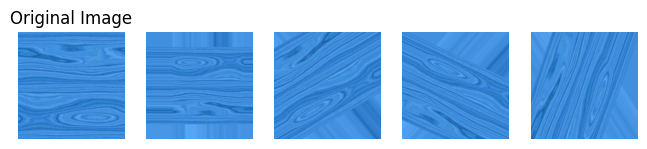

In [7]:
# Let's take the first image
sampleImage = data[0][1]
sampleImage = np.expand_dims(sampleImage, axis=0)

augmentedImages = dataGen.flow(sampleImage, batch_size=1)

fig, axes = plt.subplots(1, 5, figsize=(8,8))

axes[0].imshow( data[0][1] )
axes[0].axis('off')
axes[0].set_title('Original Image')

for i in range(1,5):
    augImage = next(augmentedImages)[0].astype('uint8') # Match RGB range of 8 bits to save memory
    axes[i].imshow(augImage)
    axes[i].axis('off')

In [8]:
IMAGES_TO_GENERATE = 400

lengthBefore = len(data)

for k in range(IMAGES_TO_GENERATE):
    className, randomImage = random.choice(data) # Unpack every data
    randomImage = np.expand_dims(randomImage, axis=0)

    augmentedImage = dataGen.flow(randomImage, batch_size=1) # Create a singular augmented image
    augmentedImage = next(augmentedImage)[0] # Extract actual augmented image

    # 0th index corresponds to the class name
    data.append( [ className,  augmentedImage] )

print( f'Added { len(data) - lengthBefore } images.' )

Added 400 images.


In [9]:
# Create the dataframe
df = pd.DataFrame(data, columns=['class', 'image'])
print( df.head() )

  class                                              image
0  wood  [[[70, 147, 226], [70, 147, 226], [70, 147, 22...
1  wood  [[[9, 35, 82], [7, 34, 81], [4, 32, 79], [0, 2...
2  wood  [[[77, 104, 130], [76, 103, 129], [75, 102, 12...
3  wood  [[[26, 87, 167], [26, 87, 167], [26, 87, 167],...
4  wood  [[[7, 25, 66], [6, 24, 65], [5, 23, 64], [4, 2...


# Building the Model

In [10]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [11]:
latent_dim = 100

In [14]:
def createGeneratorModel():
    model = Sequential()

    # Input layer
    model.add(layers.Dense(8 * 8 * 256, input_dim=latent_dim))
    model.add(layers.Reshape((8, 8, 256)))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.BatchNormalization(momentum=0.8))

    # Upsampling layers
    model.add(layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.BatchNormalization(momentum=0.8))

    model.add(layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.BatchNormalization(momentum=0.8))

    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.BatchNormalization(momentum=0.8))

    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.BatchNormalization(momentum=0.8))

    # Output layer
    model.add(layers.Conv2DTranspose(3, kernel_size=4, strides=2, padding='same', activation='sigmoid'))

    return model

def createDiscriminatorModel():
    model = Sequential()

    model.add(layers.Conv2D(64, kernel_size=4, strides=2, padding='same', input_shape=img_shape))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(128, kernel_size=4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(256, kernel_size=4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(512, kernel_size=4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.4))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

def createGAN(generator, discriminator):
    model = Sequential()

    model.add(generator)
    discriminator.trainable = False
    model.add(discriminator)

    return model

In [15]:
generator = createGeneratorModel()
generator.compile(optimizer='adam', metrics=[])

discriminator = createDiscriminatorModel()
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=[])

GAN = createGAN(generator, discriminator)
GAN.compile(optimizer='adam', loss='binary_crossentropy', metrics=[])

In [18]:
def trainGAN(generator, discriminator, gan, data, epochs=10, batch_size=64, latent_dim=100, min_loss_diff=0.001):
    halfBatch = batch_size // 2

    real = np.ones((halfBatch, 1)) # Real images
    fake = np.zeros((halfBatch, 1)) # Fake images

    DLoss = []
    GLoss = []

    last_epoch = 1

    prev_loss = None

    for epoch in range(0, epochs):
        last_epoch = epoch
        idx = np.random.randint(0, len(data), halfBatch)

        real_images = np.array( [data[i][1] for i in idx] ) # Iterate over the images (excluding class names!)

        noise = np.random.normal(0, 1, (halfBatch, latent_dim))

        fake_images = generator.predict(noise)

        discriminatorRealLoss = discriminator.train_on_batch(real_images, real)
        discriminatorFakeLoss = discriminator.train_on_batch(fake_images, fake)
        discriminatorLoss = np.average([discriminatorRealLoss, discriminatorFakeLoss])

        if prev_loss:
            if abs(prev_loss - discriminatorLoss) < min_loss_diff:
                print(f"Early stopping at epoch {epoch} due to vanishing gradient.")
                break

        prev_loss = discriminatorLoss

        noise = np.random.normal(0, 1, (halfBatch, latent_dim))
        generatorLoss = gan.train_on_batch(noise, real)

        DLoss.append(discriminatorLoss)
        GLoss.append(generatorLoss)

    epochs_array = range(1, last_epoch + 1)

    fig, axes = plt.subplots(1, 2)
    axes[0].plot( epochs_array, DLoss )
    axes[0].set_title('Discriminator Loss over Epochs')
    axes[1].plot( epochs_array, GLoss )
    axes[1].set_title('Generator Loss over Epochs')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 760ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 930ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 966ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 941ms/step
Early stopping at epoch 17 due to vanishing gradient.


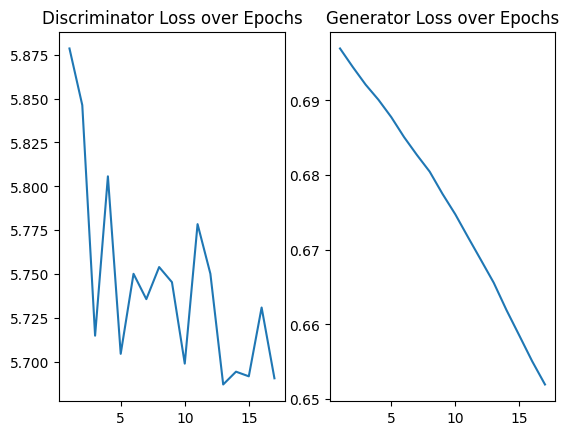

In [19]:
trainGAN(
    generator,
    discriminator,
    GAN,
    data,
    1000
)

# Model Generation

In [20]:
def generate_image():
    random_noise = np.random.normal(0, 1, (1, latent_dim))
    generated_image = generator.predict(random_noise)

    # We'd like to normalize the range of the pixels since the sigmoid is in range (-1, 1) therefore
    generated_image = (generated_image + 1)/2

    plt.imshow( generated_image[0] )
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


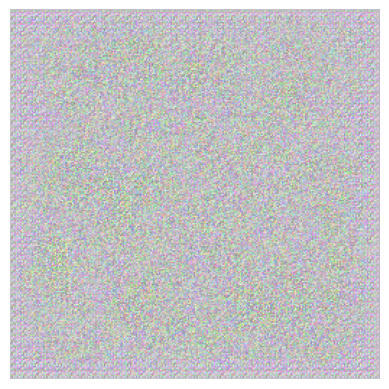

In [23]:
generate_image()

# Utilizing transfer Learning

In [17]:
!sudo dd if=/dev/zero of=/swapfile bs=1M count=4096
!sudo mkswap /swapfile
!sudo swapon /swapfile

4096+0 records in
4096+0 records out
4294967296 bytes (4.3 GB, 4.0 GiB) copied, 30.1102 s, 143 MB/s
mkswap: /swapfile: insecure permissions 0644, fix with: chmod 0600 /swapfile
Setting up swapspace version 1, size = 4 GiB (4294963200 bytes)
no label, UUID=a8b2e9a9-713a-44be-aee0-f2ada7092058
swapon: /swapfile: insecure permissions 0644, 0600 suggested.
swapon: /swapfile: swapon failed: Invalid argument


In [4]:
!git clone https://github.com/NVlabs/stylegan3
%cd stylegan3

Cloning into 'stylegan3'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 212 (delta 0), reused 0 (delta 0), pack-reused 208 (from 2)
Receiving objects: 100% (212/212), 4.16 MiB | 18.30 MiB/s, done.
Resolving deltas: 100% (101/101), done.
/content/stylegan3


In [13]:
!python dataset_tool.py \
    --source='/content/drive/MyDrive/GAN data/data/wood' \
    --dest='/content/wood_textures.zip' \
    --resolution=256x256

Traceback (most recent call last):
  File "/content/stylegan3/dataset_tool.py", line 456, in <module>
    convert_dataset() # pylint: disable=no-value-for-parameter
    ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
         ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/click/core.py", line 788, in invoke
    return __callback(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/click/decorators.py", line 33, in new_func
    return f(get_current_context(), *args, **kwargs)
           ^^^^^^^^^^^

In [18]:
!wget https://api.ngc.nvidia.com/v2/models/nvidia/research/stylegan3/versions/1/files/stylegan3-t-ffhq-1024x1024.pkl

!python train.py \
    --outdir='/content/drive/MyDrive/GAN data/models/sg3/' \
    --cfg=stylegan3-t \
    --data='/content/wood_textures.zip' \
    --gpus=1 \
    --batch=16 \
    --snap=10 \
    --gamma=0.5

--2025-03-04 20:12:57--  https://api.ngc.nvidia.com/v2/models/nvidia/research/stylegan3/versions/1/files/stylegan3-t-ffhq-1024x1024.pkl
Resolving api.ngc.nvidia.com (api.ngc.nvidia.com)... 35.165.30.77, 44.242.39.124
Connecting to api.ngc.nvidia.com (api.ngc.nvidia.com)|35.165.30.77|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://xfiles.ngc.nvidia.com/org/nvidia/team/research/models/stylegan3/versions/1/files/stylegan3-t-ffhq-1024x1024.pkl?versionId=Pq0TsLpbrJL8kNRN4xGQsr_DcEvFQ4xJ&ssec-algo=AES256&ssec-key=0XSD2zWGWnBjjC62qbXtFxh0ZBU3RpGPCrmQdSDXw595LQp0LKUdP%2FWDB2aXYlH7HDRyaKqFTD1ifV%2B9VmIzxMoPpYTusAbTtJ977qNXexzlv6HpkMXYlGaaKSTg5RQG61eHY7BLePVsQX676TvQC6ex0QH4fHfgf6ydHGygdOijDMuw3jhdfWR9nU5j6t0VphcTHgMA44bV8BQNaFWtiwMl0Vkll2lzFwuFuLrKKeayKNfPncYdzWxR%2B4weuRET2N13BoQFsdOkeOj3Nt3dlJctkWP0eSRydO%2F5hUlXVUcMkiCr8kqkiG6mL4EHzE6fjNm5l3%2Fjxz5WtCrGlakqOIe2tQ%2BvEWIcatN5qzj2J6AKhtkBs%2Fvc9XfZC7d1aReMUAZcz%2FfVzdtgpcPFfEf2UWlwCN%2FxBqOijtUKvO3ZwFo4uv

In [16]:
!python gen_images.py \
    --network='/content/drive/MyDrive/GAN data/models/sg3/network-snapshot-00010.pkl' \
    --seeds=0-5 \
    --outdir='/content/drive/MyDrive/generated_textures/'

Loading networks from "/content/drive/MyDrive/GAN data/models/sg3/network-snapshot-00010.pkl"...
Traceback (most recent call last):
  File "/content/stylegan3/gen_images.py", line 143, in <module>
    generate_images() # pylint: disable=no-value-for-parameter
    ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
         ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/click/core.py", line 788, in invoke
    return __callback(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/stylegan3/gen_images.py", line 107, in generate_images